# Пункт d

### Константы

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
n = 100
theta = 10
beta = 0.95
U_0_025 = -1.96
U_0_975 = 1.96

#для bootstrap
N_non_param = 10000
N_param = 1000000

### Создание выборки

In [5]:
def sample_from_distribution(size: int, theta = theta):
    """для моделирования случайной величины разыгрываем равномерно
    распределённую сл.вел. ~ R(0,1);
    Выражаем x из значения функции распределения"""
    function_values_arr = np.random.uniform(0, 1, size)
    sample = (1 - function_values_arr)**(-1/(theta - 1))
    return sample

sample = sample_from_distribution(n)
print(sample)

[1.36994977 1.13320571 1.21681287 1.01273411 1.3766749  1.05252642
 1.11984637 1.18197376 1.10522916 1.06815933 1.084397   1.00300911
 1.0188602  1.23459322 1.03249267 1.13230255 1.25132528 1.02313234
 1.02462112 1.2232365  1.11536997 1.09899331 1.1577672  1.33212306
 1.05998261 1.22389657 1.0845292  1.07608619 1.19037318 1.02484562
 1.04043706 1.30383723 1.00425124 1.01018727 1.01228143 1.11392046
 1.19755949 1.01559895 1.0131026  1.02732835 1.06606521 1.17868544
 1.20232167 1.03667849 1.10979479 1.28466625 1.00161102 1.09308398
 1.16455121 1.00619598 1.07330728 1.03904556 1.10966496 1.08665922
 1.00338242 1.26472788 1.20803575 1.20917006 1.29294736 1.14803798
 1.08279491 1.05723226 1.02308157 1.01123593 1.04826175 1.07753444
 1.02830588 1.09200631 1.02231916 1.0021059  1.05084105 1.06741553
 1.07427826 1.08319302 1.43777196 1.09636266 1.9216943  1.1506333
 1.16421439 1.55279579 1.21197452 1.01949922 1.23289257 1.12622648
 1.12654962 1.23195374 1.04954467 1.07151519 1.08959786 1.00106

### Точный интевал для медианы

In [ ]:
from scipy.stats import gamma

T = np.sum(np.log(sample))

alpha = 1 - beta
gamma_0_975 = gamma.ppf(1-alpha/2, a=n, scale=2)
gamma_0_025 = gamma.ppf(alpha/2, a=n, scale=2)

exact_median_left = 2**((2 * T) / gamma_0_975)
exact_median_right = 2**((2 * T) / gamma_0_025)

l_median_exact = exact_median_right - exact_median_left

print(exact_median_left)
print(exact_median_right)
print(l_median_exact)

1.0713377507633928
1.1074691366808291
0.036131385917436365


### Асимтотический интервал медиана

In [10]:
theta_omp_est = 1 + n / np.sum(np.log(sample))
median_est = 2 ** (1 / (theta - 1))

asimptotic_median_left=median_est-(U_0_975*np.log(2)*median_est)/((theta_omp_est-1)*np.sqrt(n))
asimptotic_median_right=median_est-(U_0_025*np.log(2)*median_est)/((theta_omp_est-1)*np.sqrt(n))

l_median_asimptotic = asimptotic_median_right - asimptotic_median_left

print(asimptotic_median_left)
print(asimptotic_median_right)
print(l_median_asimptotic)

1.0624778512133308
1.0976416265712814
0.035163775357950566


### Асимтотический интервал тета

In [15]:
asimptotic_theta_left = theta_omp_est - (U_0_975*(theta_omp_est - 1))/np.sqrt(n)
asimptotic_theta_right = theta_omp_est - (U_0_025*(theta_omp_est - 1))/np.sqrt(n)
l_asimptotic_theta = asimptotic_theta_right - asimptotic_theta_left

print(asimptotic_theta_left)
print(asimptotic_theta_right)
print(l_asimptotic_theta)

7.709958856144477
10.981481084513426
3.2715222283689487


# Пункт t

### Непараметрический bootstrap

In [18]:
def non_param_bootstrap_deltas(sample: np.ndarray, N):
    """N-количество выборок, создаваемы bootstrap"""
    sample_theta = 1 + n /(np.sum(np.log(sample)))
    deltas = np.zeros(N)
    for i in range(N):
        bootstrap_sample = np.random.choice(
            sample,
            size = sample.size,
            replace = True
        )
        bootstrap_theta = 1 + n/(np.sum(np.log(bootstrap_sample)))
        deltas[i] = sample_theta - bootstrap_theta
    return deltas

variation_series_np_b = np.sort(non_param_bootstrap_deltas(sample, N_non_param))
k1 = int((1-beta) * N_non_param/2)
k2 = int((1+beta) * N_non_param/2)

sample_theta = 1 + n /(np.sum(np.log(sample)))

non_param_b_left = sample_theta - variation_series_np_b[k2]
non_param_b_right = sample_theta - variation_series_np_b[k1]

l_non_param_b = non_param_b_right - non_param_b_left

print(non_param_b_left)
print(non_param_b_right)
print(l_non_param_b)

8.011300128379531
11.156083174470945
3.1447830460914137


### Параметрический bootstrap

In [21]:
def param_bootstrap_deltas(sample, N):
    deltas = np.zeros(N)
    theta_param_b_est = 1 + n / np.sum(np.log(sample))
    for i in range(N):
        bootstrap_sample = sample_from_distribution(n, theta_param_b_est)
        bootstrap_theta = 1 + n / np.sum(np.log(bootstrap_sample))
        
        deltas[i] = theta_param_b_est - bootstrap_theta
    return deltas

variation_series_b = np.sort(param_bootstrap_deltas(sample, N_param))
k1 = int((1-beta) * N_param/2)
k2 = int((1+beta) * N_param/2)

sample_theta = 1 + n /(np.sum(np.log(sample)))

param_b_left = sample_theta - variation_series_b[k2]
param_b_right = sample_theta - variation_series_b[k1]

l_param_b = param_b_right - param_b_left

print(param_b_left)
print(param_b_right)
print(l_param_b)

7.922421152386437
11.262610211178178
3.340189058791741


# Пункт f

### Сравнение доверительных интервалов, медиана

C:\Users\hp\AppData\Local\Temp\ipykernel_22884\107336004.py:24: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('|').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x1, i, s=80, color=colors[i], edgecolor='black',
C:\Users\hp\AppData\Local\Temp\ipykernel_22884\107336004.py:26: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('|').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x2, i, s=80, color=colors[i], edgecolor='black',


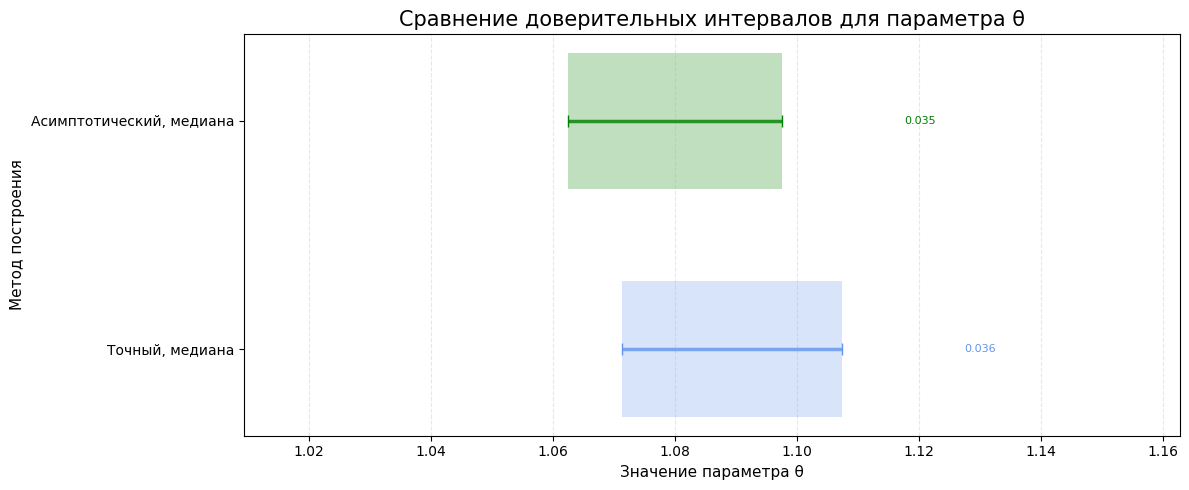

In [23]:
segments = [
    [exact_median_left, exact_median_right],
    [asimptotic_median_left, asimptotic_median_right],
]

names = [
    "Точный, медиана",
    "Асимптотический, медиана",
]
colors = ["cornflowerblue", "green"]

fig, ax = plt.subplots(figsize=(12, 5))

all_points = [point for interval in segments for point in interval]
x_min = min(all_points) - 0.05 * abs(min(all_points)) if min(all_points) > 0 else min(all_points) - 0.1
x_max = max(all_points) + 0.05 * abs(max(all_points)) if max(all_points) > 0 else max(all_points) + 0.1

for i, (x1, x2) in enumerate(segments):
    width = x2 - x1
    ax.barh(y=i, width=width, left=x1, height=0.6, 
            alpha=0.25, color=colors[i], edgecolor='none')
    ax.hlines(y=i, xmin=x1, xmax=x2, linewidth=2.5, color=colors[i], alpha=0.8)

    ax.scatter(x1, i, s=80, color=colors[i], edgecolor='black', 
               linewidth=1, zorder=5, marker='|')
    ax.scatter(x2, i, s=80, color=colors[i], edgecolor='black', 
               linewidth=1, zorder=5, marker='|')
    ax.text(x2 + 0.02, i, f'{width:.3f}', 
            ha='left', va='center', fontsize=8, color=colors[i])

ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_yticks(range(len(segments)))
ax.set_yticklabels(names, fontsize=10)
ax.set_xlim(x_min, x_max)
ax.set_xlabel('Значение параметра θ', fontsize=11)
ax.set_ylabel('Метод построения', fontsize=11)
ax.set_title('Сравнение доверительных интервалов для параметра θ', fontsize=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

### Сравнение доверительных интервалов, тета

C:\Users\hp\AppData\Local\Temp\ipykernel_22884\1119885710.py:26: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('|').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x1, i, s=80, color=colors[i], edgecolor='black',
C:\Users\hp\AppData\Local\Temp\ipykernel_22884\1119885710.py:28: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('|').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x2, i, s=80, color=colors[i], edgecolor='black',


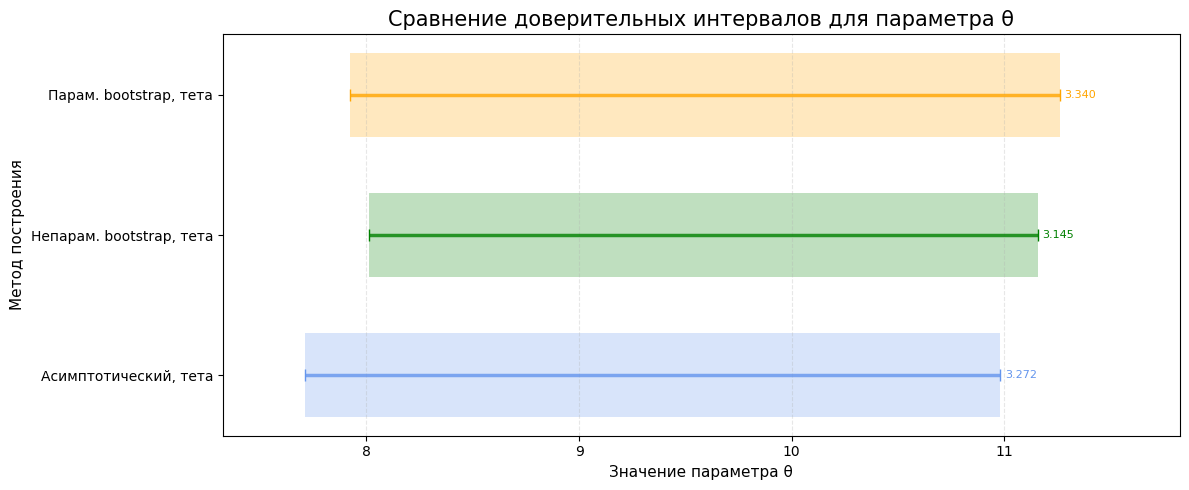

: 

In [ ]:
segments = [
    [asimptotic_theta_left, asimptotic_theta_right],
    [non_param_b_left, non_param_b_right],
    [param_b_left, param_b_right]
]

names = [
    "Асимптотический, тета",
    "Непарам. bootstrap, тета",
    "Парам. bootstrap, тета",
]
colors = ["cornflowerblue", "green", "orange"]

fig, ax = plt.subplots(figsize=(12, 5))

all_points = [point for interval in segments for point in interval]
x_min = min(all_points) - 0.05 * abs(min(all_points)) if min(all_points) > 0 else min(all_points) - 0.1
x_max = max(all_points) + 0.05 * abs(max(all_points)) if max(all_points) > 0 else max(all_points) + 0.1

for i, (x1, x2) in enumerate(segments):
    width = x2 - x1
    ax.barh(y=i, width=width, left=x1, height=0.6, 
            alpha=0.25, color=colors[i], edgecolor='none')
    ax.hlines(y=i, xmin=x1, xmax=x2, linewidth=2.5, color=colors[i], alpha=0.8)

    ax.scatter(x1, i, s=80, color=colors[i], edgecolor='black', 
               linewidth=1, zorder=5, marker='|')
    ax.scatter(x2, i, s=80, color=colors[i], edgecolor='black', 
               linewidth=1, zorder=5, marker='|')
    ax.text(x2 + 0.02, i, f'{width:.3f}', 
            ha='left', va='center', fontsize=8, color=colors[i])

ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_yticks(range(len(segments)))
ax.set_yticklabels(names, fontsize=10)
ax.set_xlim(x_min, x_max)
ax.set_xlabel('Значение параметра θ', fontsize=11)
ax.set_ylabel('Метод построения', fontsize=11)
ax.set_title('Сравнение доверительных интервалов для параметра θ', fontsize=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()